In [1]:
!pip install roboflow ultralytics opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 121.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 9.5 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2


In [2]:
from roboflow import Roboflow
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [3]:
rf = Roboflow(api_key="uSGO5gTPGNiH2J20SPiW")
project = rf.workspace("maii-sediik").project("brain-tumor-m2pbp-e64ef")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to brain-tumor-1 in yolov11:: 100%|██████████| 47525/47525 [00:04<00:00, 11380.23it/s]


In [4]:
! wget https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo11s.pt

--2026-09-10 14:01:29--  https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo11s.pt
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/ce5e8695-cf08-4fa0-812a-7a83f8ef8345?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-10T14%3A37%3A11Z&rscd=attachment%3B+filename%3Dyolo11s.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-10T13%3A37%3A07Z&ske=2026-09-10T14%3A37%3A11Z&sks=b&skv=2018-11-09&sig=2hnihLuEsyDIXZMNCqsuf28r4qfJocKFZeybl5kuEPA%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4OTA1MDY5MCwibmJmIjoxNzg5MDQ4ODkwLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud

In [5]:
model=YOLO("yolo11s.pt")

In [6]:
result = model.train(
    data="/content/brain-tumor-1/data.yaml",
    patience=20,     # dataset is ~9.9k images (RF100 benchmark) - patience=5 risks stopping on normal noise
    epochs=30,      # ceiling only; early stopping will cut this short once mAP50-95 plateaus
    batch=32,
    imgsz=640,
    name='custom_yolo11_train'
)

Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/brain-tumor-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_yolo11_train, nbs=64, nm

In [7]:
metrics = model.val()

print(f"mAP50     {metrics.box.map50:.3f}")
print(f"mAP50-95  {metrics.box.map:.3f}")
print(f"Precision {metrics.box.p.mean():.3f}")
print(f"Recall    {metrics.box.r.mean():.3f}")

Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11s summary (fused): 100 layers, 9,413,961 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 921.1±268.3 MB/s, size: 19.6 KB)
val: Scanning /content/brain-tumor-1/valid/labels.cache... 1980 images, 16 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1980/1980 692.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 124/124 11.3it/s 11.0s
                   all       1980       4381      0.894      0.726      0.799      0.524
                label0       1246       1246       0.86      0.654      0.742      0.445
                label1       1945       1945      0.918      0.826      0.876       0.63
                label2       1190       1190      0.903      0.699       0.78      0.496
Speed: 0.7ms preprocess, 1.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /conten

In [8]:
results=model.predict(
    source='/content/brain-tumor-1/test/images/volume_100_slice_48_jpg.rf.2f17cc653162e124c2b0e64eb566fe7b.jpg',
    iou=0.7,
    conf=0.45,
    save=True,
    save_txt=True,
    show=False
)


image 1/1 /content/brain-tumor-1/test/images/volume_100_slice_48_jpg.rf.2f17cc653162e124c2b0e64eb566fe7b.jpg: 640x640 1 label0, 1 label1, 1 label2, 9.0ms
Speed: 1.9ms preprocess, 9.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
1 label saved to /content/runs/detect/predict/labels


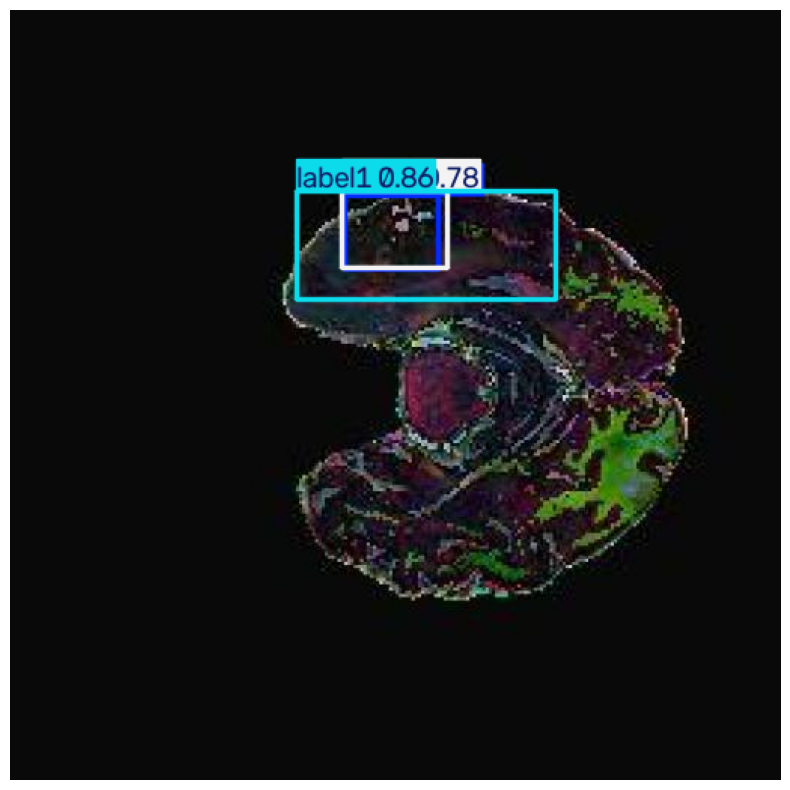

In [9]:
plt.figure(figsize=(20,10))
plt.imshow(cv2.cvtColor(results[0].plot(),cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [10]:
import shutil, os

# Package the best checkpoint (already auto-selected by Ultralytics) for GitHub
best_weights = "runs/detect/custom_yolo11_train/weights/best.pt"
out_dir = "brain-tumor-yolo11-best"
os.makedirs(out_dir, exist_ok=True)
shutil.copy(best_weights, os.path.join(out_dir, "best.pt"))
shutil.copy("/content/brain-tumor-1/data.yaml", os.path.join(out_dir, "data.yaml"))
print(f"Saved best YOLO weights to ./{out_dir}")

Saved best YOLO weights to ./brain-tumor-yolo11-best


In [16]:
results=model.predict(
    source='/content/brain-tumor-1/test/images/volume_101_slice_68_jpg.rf.1a288b03f4588da66a7a5565bc8339f2.jpg',
    iou=0.7,
    conf=0.45,
    save=True,
    save_txt=True,
    show=False
)


image 1/1 /content/brain-tumor-1/test/images/volume_101_slice_68_jpg.rf.1a288b03f4588da66a7a5565bc8339f2.jpg: 640x640 1 label1, 1 label2, 10.3ms
Speed: 2.1ms preprocess, 10.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
2 labels saved to /content/runs/detect/predict/labels


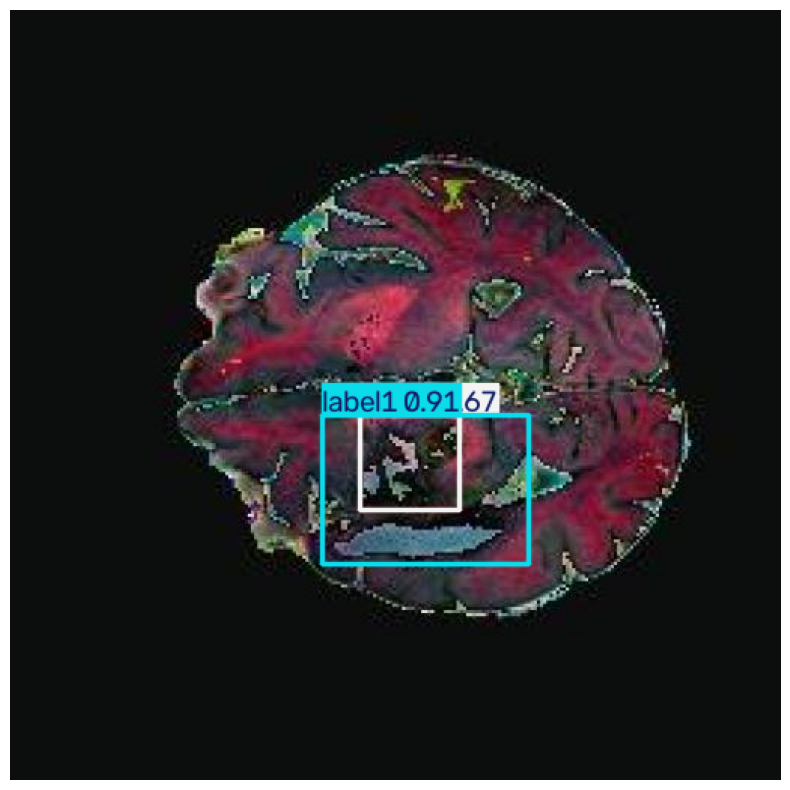

In [17]:
plt.figure(figsize=(20,10))
plt.imshow(cv2.cvtColor(results[0].plot(),cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import os
import shutil

# 2. Define source and destination paths
source_dir = "./runs"
destination_dir = "/content/drive/MyDrive/yolo11_train"

# 3. Copy the entire folder and all its contents
if os.path.exists(destination_dir):
    shutil.rmtree(
        destination_dir
    )  # Clean up existing directory if it exists to avoid conflicts

shutil.copytree(source_dir, destination_dir)
print("Successfully copied all files and folders to Google Drive!")

Successfully copied all files and folders to Google Drive!
